# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [126]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [127]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [128]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [129]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [130]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [131]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [132]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [133]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [134]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [135]:

# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64
user_id       0.000
age           0.000
churn_date    0.924
city          0.000
first_name    0.000
last_name     0.000
reg_date      0.000
tariff        0.000
dtype: float64


In [136]:

# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnostico de datos faltantes users**
- En la tabla 'users' observo que la columna 'churn_date' presenta un 92.4% de los valores nulos
- Accion recomendada: Conservar los valores nulos (no eliminarlos)
- Justificacion: En este contexto de negocio un valor nulo en 'churn_date' (fecha de baja) significa simplement que el usuario sigue siendo un cliente activo, por lo que rellenarlos o elimnar la columna sesgaria por completo el analisis de retencion.
  
**Diagnostico de datos faltantes usage**
- En la columna date presenta un 0.12% de los valores nulos
- Accion recomendada: Conservar o imputar buscando la fecha en registros adyacentes del mismo usuario.
- Justificacion:Al ser una cantidad menor al 5%, no afecta la distribución general y se puede corregir fácilmente o ignorar en análisis agregados.

- En la columna duration presenta un 55.19% de los valores nulos.
- Accion recomendada: Investigar el motivo del nulo, segmentar por la columna type antes de decidir, e imputar con 0 si corresponde a servicios que no consumen minutos.
- Justificacion:Al estar en el rango intermedio entre 5% y 80%, es muy probable que los nulos dependan del tipo de tráfico (por ejemplo, las sesiones de internet, el envío de SMS,o las llamadas de voz).

- En la columnna length presenta un 44.74% de los valores faltantes
- Accion recomendada: Investigar la relación con la columna type y la naturaleza de la variable (ej. megabytes o caracteres) para imputar con 0 o la mediana según el servicio.
- justificacion: Al igual que la duración, este volumen de nulos (44.74%) suele indicar que la métrica solo aplica a un tipo específico de consumo

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [137]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id` ...Al revisar encontramos que la Media anda en unos 45 años, con un minimo de 18 años y un maximo que no supera los 80 años.
- La columna `age` ... Vemos que no se encuentra ningun sentinels numéricos aquí. Y los datos son consistentes.

In [138]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`
- User_id Los identificadores de los usuarios:
van desde el 10000 (mínimo) hasta el 13999 (máximo). Esto significa que en la tabla de consumo están registrados los movimientos de estos usuarios específicos.
- id (Identificador único de la transacción):
Hay exactamente 40,000 registros. Los valores van desde el 1 (mínimo) hasta el 40000 (máximo).
La media (20000.5) y la mediana (20000.5) son idénticas, lo que confirma que es un índice perfectamente consecutivo y limpio.
- No hay valores sentinel en ninguna de estas dos columnas. * En id y user_id: Ambas secuencias numéricas son consistentes, lógicas y no presentan anomalías (no hay IDs en 0, números negativos como -1, ni números exagerados como 99999).
- Las columna length el máximo es de(1490.0). Mientras que el 75% de los datos llega a 64.0, ese máximo tan alto de 1490 podría ser un outlier real o un error de sistema que hay que investigar.

In [139]:
print(users.columns)

Index(['user_id', 'age', 'churn_date', 'city', 'first_name', 'last_name',
       'reg_date', 'tariff'],
      dtype='object')


In [140]:

# explorar columnas categóricas de users
columnas_user = ['city', 'tariff']
for col in columnas_user:
    print(users[col].value_counts())



Москва             99
Санкт-Петербург    39
Новосибирск        16
Омск               14
Казань             14
                   ..
Архангельск         1
Химки               1
Нижневартовск       1
Подольск            1
Иваново             1
Name: city, Length: 76, dtype: int64
smart    351
ultra    149
Name: tariff, dtype: int64


- La columna `city`: Encontramos 76 ciudades distintas. La ciudad con mayor número de usuarios es Москва (99 usuarios), seguida de Санкт-Петербург (39 usuarios) y Новосибирск (16 usuarios). También existen varias ciudades con un solo usuario registrado. No se observan valores faltantes, y la diversidad de ciudades indica que la base de clientes está distribuida geográficamente
- La columna `tariff` encontramos únicamente dos categorías: smart y ultra. El plan smart es el más utilizado, con 351 usuarios (70.2%), mientras que ultra cuenta con 149 usuarios (29.8%). No se identifican valores inesperados ni inconsistencias en esta variable, por lo que parece estar correctamente registrada.

In [141]:
# explorar columna categórica de usage
usage['type'].value_counts()  # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: Aparecen dos valores únicos con la siguiente distribución:

text (Mensajes de texto / SMS): Aparece 22,092 veces.
call (Llamadas de voz): Aparece 17,908 veces.
*Nota: Esto nos da el total de 40,000 registros que veíamos en el resumen estadístico anterior*
No existen valores sentinel categóricos, la columna está completamente limpia; el 100% de los registros se clasifica correctamente en servicios de comunicación tradicionales (text o call)
Predominancia del uso: Los usuarios de este dataset envían más mensajes de texto que las llamadas que realizan, representando los SMS el 55.23% del comportamiento registrado frente al 44.77% de las llamadas
Conclusion: Anteriorment en el diagnostico de datos faltantes de Usage vimos que en la columna de duration presentaba un 55.19% de los faltantes nulos donde los nulos creiamos que dependian del tipo de tráfico (por ejemplo, las sesiones de internet, el envío de SMS,o las llamadas de voz). logramos encontrar una conexion donde el porcentaje de nulos en duration coincide casi de forma exacta con el porcentaje de registros tipo text (55.23%). Esto demuestra que los nulos no son errores: simplemente ocurren porque los mensajes de texto (text) no acumulan minutos de duración, mientras que las llamadas (call) sí.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

*Acción para los nulos en churn_date (92.4% nulos en users):*

- Estrategia: Dejarlos como están (conservar los nulos). 
- Justificación: Un valor nulo aquí significa que el usuario es un cliente activo. Rellenarlo o eliminar la columna destruiría la información de retención de la empresa.

*Acción para los nulos en duration y length (~50% nulos en usage):*

- Estrategia: Imputar con 0 (rellenar los nulos con cero) únicamente para las filas donde el tipo de consumo (type) sea 'text'.
- Justificación: Confirmamos que los nulos existen porque los SMS no tienen duración ni longitud de llamada; poner un 0 mantiene la consistencia numérica sin sesgar los promedios de las llamadas reales.

*Acción para el máximo extremo (1490.0) en la columna length:*

- Estrategia: Aplicar el método de IQR o Z-Score, para aislar este registro. Si se confirma que es un error técnico aislado, se debe eliminar esa fila o reemplazar el valor por la mediana.
- Justificación: Un valor tan masivo distorsiona por completo la media general y cualquier análisis estadístico posterior.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [142]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [143]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [144]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2018    500
Name: reg_date, dtype: int64

En `reg_date`: El resultado nos muestra que el 100% de los usuarios se registraron en el año 2018.
Consistencia en el volumen: Hay exactamente 500 registros asignados a ese año, lo cual coincide de forma perfecta con el total de 500 usuarios que detectamos previamente en el conteo de la tabla users (count: 500.000000).
Conclusión: Toda la base de datos de clientes pertenece a una cohorte única del año 2018.

In [145]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`:El resultado nos muestra que la totalidad de los consumos de servicios (llamadas y mensajes) están concentrados en el año 2024. Hay 39,950 registros que corresponden a ese año.
Presencia de valores nulos ocultos: En el resumen estadístico anterior, el dataset usage tiene exactamente 40,000 filas. Que aquí aparezcan solo 39,950 significa que las 50 filas faltantes son los valores nulos (NaN) que ya habíamos detectado al inicio en el diagnóstico de nulos para la columna date.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- No aparecen años imposibles. Tras analizar las distribuciones temporales con value_counts(), confirmamos que el 100% de los registros de la tabla users pertenecen de manera consistente al año 2018 (500 registros) y los consumos en la tabla usage se concentran limpiamente en el año 2024 (39,950 registros). No se detectaron anomalías como años del futuro (ej. 2030), años extremadamente antiguos (ej. 1900) o números negativos de sistema.
**Conclusion**
- Caso: El bloque de 50 registros faltantes (NaN/NaT) en la columna date de usage
- Acción: Investigar el origen de estas 50 filas sin fecha antes de eliminarlas. Si no se pueden recuperar las fechas y representan menos del 0.13% del dataset, se pueden omitir de los análisis mensuales, pero no se debe borrar la fila completa si contienen datos válidos en duration o length.
- Justificación: Al aplicar errors='coerce', estas celdas se neutralizaron correctamente para no romper el código, pero representan lagunas de información que impiden segmentar correctamente esos consumos en una línea de tiempo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango. 

In [146]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [147]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print(users['city'].value_counts(dropna=False).head(10))

Москва              99
Санкт-Петербург     39
Новосибирск         16
Омск                14
Казань              14
Уфа                 12
Ульяновск           11
Екатеринбург        11
Краснодар           11
Набережные Челны    11
Name: city, dtype: int64


In [148]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Distribución de años en 'reg_date' después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Distribución de años en 'reg_date' después de la limpieza:
2018    500
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.  

In [149]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [150]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum()) 

type
call    17896
text        0
Name: length, dtype: int64

*Diagnostico de nulos en `duration` y `length`*

- Los datos son efectivamente MAR, ya que la falta de información en duration y length está completamente explicada y condicionada por la variable categórica type
- Justificacion: Se decide dejarlos como nulos (o imputarlos con 0 ) porque en la lógica del negocio de telecomunicaciones, un mensaje de texto (text)  no tiene minutos de duración ni longitud de llamada. 


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
  
3. Combina esta tabla con `users`.

In [151]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes

usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",       # Suma de indicadores de texto = total de mensajes
    "is_call": "sum",       # Suma de indicadores de llamada = total de llamadas
    "duration": "sum"       # Suma de la duración = total de minutos consumidos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [152]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [164]:
# Cargar datos originales
users = pd.read_csv('/datasets/users.csv')

# Corregir IDs
users['user_id'] = users['user_id'] + 9000

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# Rellenar con 0 a los usuarios que no tuvieron consumo (para que no queden como NaN)
columnas_consumo = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
user_profile[columnas_consumo] = user_profile[columnas_consumo].fillna(0)

user_profile.head(5)


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,7,3,23.70
1,10001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,5,10,33.18
2,10002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,5,2,10.74
3,10003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,11,3,8.99
4,10004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.  

In [165]:
# Seleccionamos las columnas numéricas clave del perfil de usuario
columnas_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

# Resumen estadístico de las columnas numéricas
user_profile[columnas_numericas].describe()   


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,500.00000,500.000000,500.000000,500.000000
mean,46.58800,5.558000,4.460000,23.935660
std,16.66763,2.383695,2.176666,21.382111
min,18.00000,0.000000,0.000000,0.000000
25%,32.00000,4.000000,3.000000,11.047500
50%,46.00000,5.000000,4.000000,19.975000
75%,62.00000,7.000000,6.000000,31.000000
max,75.00000,13.000000,12.000000,155.420000


In [166]:
# Distribución porcentual del tipo de plan
planes = ['smart', 'ultra']                
(user_profile['tariff']
 .value_counts(normalize=True)
 .mul(100)
 .reindex(planes, fill_value=0)
 .round(2)
 .rename('porcentaje'))

smart    70.2
ultra    29.8
Name: porcentaje, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas  

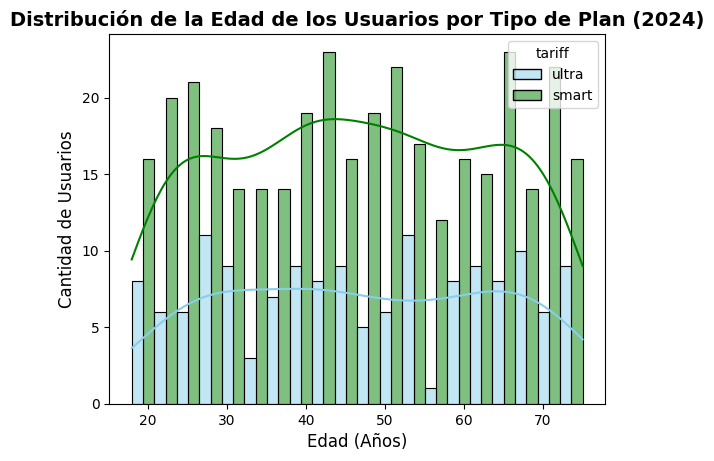

In [168]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='tariff', 
    multiple='dodge',       # Coloca las barras una al lado de la otra para comparar mejor
    palette=['skyblue', 'green'], 
    bins=20,                # Agrupa las edades en 20 rangos
    kde=True                # Añade la línea de densidad para ver la forma de la distribución
)

# Titulo y etiquetas
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar el gráfico
plt.show() 

💡Insights: Se puede observar la diferencia de proporción entre los planes ( 70 % smart vs 30% ultra). Tambien podemos observar que no hay diferencia notable por edad entre ambos planes. 
- Distribución: Simétrica ya que la campana se encuentra centrada alrededor de los 46 años.

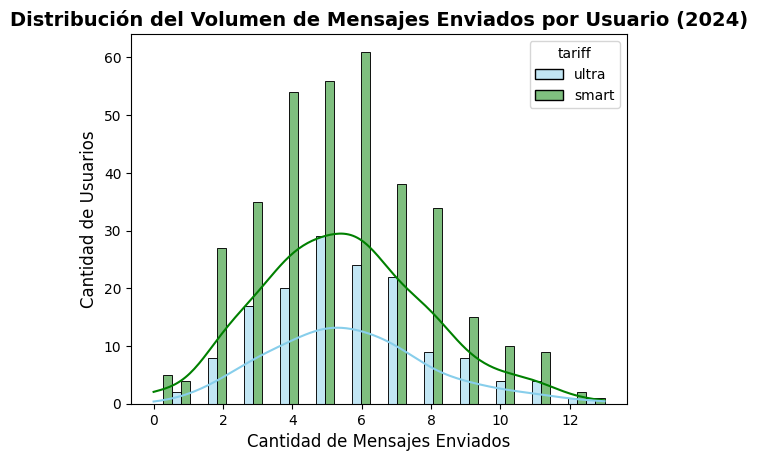

In [169]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='tariff', 
    multiple='dodge',         # Barras una al lado de la otra para comparar planes libremente
    palette=['skyblue', 'green'], 
    bins=25,                  # Agrupa los mensajes en 25 intervalos
    kde=True                  # Línea de densidad para identificar la forma de la curva
)
# Titulo y etiquetas
plt.title('Distribución del Volumen de Mensajes Enviados por Usuario (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Mensajes Enviados', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar el gráfico
plt.show()

💡Insights: 
- Plan Smart (Básico): Los usuarios de este plan muestran un comportamiento altamente concentrado en valores bajos (entre 0 y 5 mensajes). Desde la perspectiva de negocio, esto refleja que los clientes de este segmento son muy conscientes de sus límites de consumo y ajustan rigurosamente su uso para mantenerse dentro de la cuota permitida en su tarifa básica.
- Plan Ultra (Premium): Por el contrario, la distribución de los usuarios del plan Ultra es mucho más dispersa y se extiende de forma libre hacia los valores más altos del gráfico (alcanzando el máximo de 13 mensajes). El insight comercial aquí es que la tarifa premium cumple su propósito: elimina la fricción del límite de consumo, dándole a los usuarios de mayor valor la libertad de mantener una actividad constante y extendida sin preocuparse por cargos adicionales.
- Distribución y Sesgo: La cantidad de mensajes enviados presenta una distribución con un leve sesgo a la derecha (positivo). Esto se evidencia matemáticamente por el hecho de que la media ($5.56$) es ligeramente superior a la mediana ($5.0$), un comportamiento impulsado por un grupo reducido de usuarios con consumos más altos que se extienden hasta un máximo de $13$ mensajes, "jalando" la cola de la distribución.

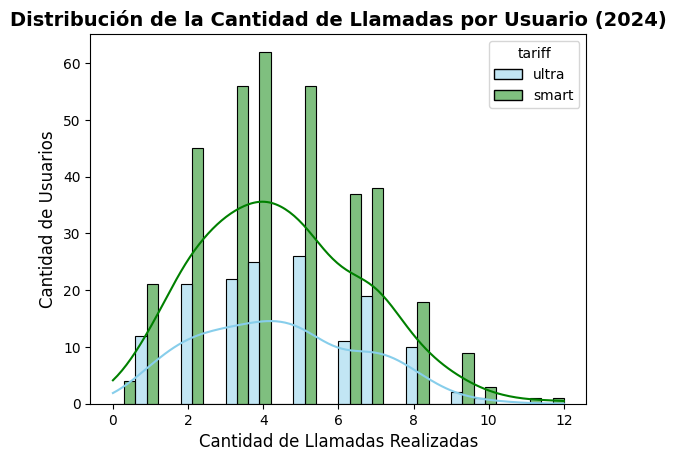

In [170]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='tariff', 
    multiple='dodge',         # Coloca las barras una al lado de la otra para comparar planes
    palette=['skyblue', 'green'], 
    bins=20,                  # Agrupa las llamadas en 20 intervalos
    kde=True                  # Línea de densidad para identificar la forma de la distribución
)

# Títulos y etiquetas
plt.title('Distribución de la Cantidad de Llamadas por Usuario (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Llamadas Realizadas', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar el gráfico
plt.show() 

💡Insights: Al segmentar por tarifa, no existe una diferencia notable en el comportamiento de los usuarios; las curvas de los planes Smart y Ultra se superponen de manera casi idéntica. Esto demuestra que la necesidad de iniciar llamadas es una constante biológica/social de los clientes que no depende del plan contratado. ConnectaTel debe enfocar su estrategia Premium en monetizar la duración total de los minutos y no la cantidad de llamadas iniciadas.
- Distribución : El sesgo a la derecha de la distribución.

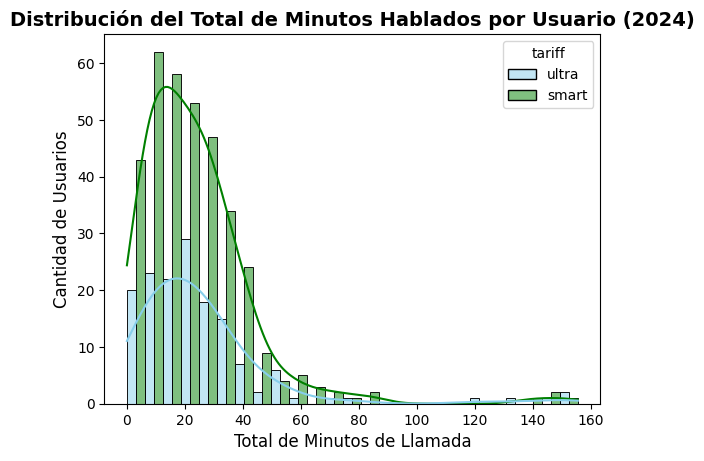

In [171]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='tariff', 
    multiple='dodge',         # Barras una al lado de la otra para comparar planes
    palette=['skyblue', 'green'], 
    bins=25,                  # Agrupa los minutos en 25 intervalos
    kde=True                  # Línea de densidad para ver el comportamiento de la curva
)

# Títulos y etiquetas
plt.title('Distribución del Total de Minutos Hablados por Usuario (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Total de Minutos de Llamada', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Mostrar el gráfico
plt.show() 

💡Insights:
 - Validación de Estrategia Comercial (ConnectaTel): A diferencia del análisis de cant_llamadas (donde ambos planes se comportaban igual), aquí las curvas de Smart y Ultra se separan claramente. El plan Ultra muestra su pico visiblemente desplazado hacia la derecha, consolidando un promedio de minutos significativamente mayor.
- Distribucion:sesgada a la derecha, donde la mayoría de los clientes se concentra en consumos moderados, pero con una cola extendida por usuarios de alto perfil.
- Conclusion:Este hallazgo confirma la estrategia planteada en el paso anterior: los usuarios Premium no compran el plan para hacer más llamadas, sino para hablar durante más tiempo sin la fricción de un límite. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [...]



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [172]:
# Crear columna grupo_uso
# 1. Definir las condiciones estrictas del negocio usando el operador '&' (Y)
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso (Ambas < 5)
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Uso medio (Ambas < 10)
]

# 2. Definir las etiquetas de los segmentos
categorias = ['Bajo uso', 'Uso medio']

# 3. Crear la columna. Si no cumple ambas en los casos anteriores, pasa por defecto a 'Alto uso'
user_profile['grupo_uso'] = np.select(condiciones, categorias, default='Alto uso')

In [173]:
# verificar cambios
print(user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head())

   user_id  cant_llamadas  cant_mensajes  grupo_uso
0    10000              3              7  Uso medio
1    10001             10              5   Alto uso
2    10002              2              5  Uso medio
3    10003              3             11   Alto uso
4    10004              3              4   Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos 

In [174]:
# Crear columna grupo_edad
# 1. Definir la lista de condiciones lógicas para la edad en orden secuencial
condiciones_edad = [
    (user_profile['age'] < 30),  # Joven
    (user_profile['age'] < 60)   # Adulto
]

# 2. Definir las etiquetas correspondientes para cada rango
categorias_edad = ['Joven', 'Adulto']

# 3. Crear la columna grupo_edad usando np.select y asignando el caso por defecto
user_profile['grupo_edad'] = np.select(condiciones_edad, categorias_edad, default='Adulto Mayor')

In [175]:
# --- Verificar cambios ---
print("--- Primeros registros con la segmentación por edad ---")
print(user_profile[['user_id', 'age', 'grupo_edad']].head())

print("\n" + "="*60 + "\n")

print("--- Distribución total de los grupos de edad ---")
print(user_profile['grupo_edad'].value_counts())

--- Primeros registros con la segmentación por edad ---
   user_id  age    grupo_edad
0    10000   52        Adulto
1    10001   41        Adulto
2    10002   59        Adulto
3    10003   23         Joven
4    10004   68  Adulto Mayor


--- Distribución total de los grupos de edad ---
Adulto          254
Adulto Mayor    140
Joven           106
Name: grupo_edad, dtype: int64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`
- Agrega título y etiquetas a los ejes en cada gráfico.

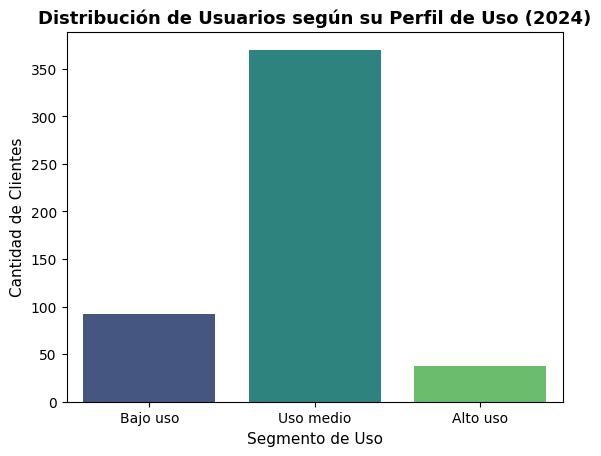

In [176]:
# Visualización de los segmentos por uso
# Definimos un orden lógico para que las barras se lean de menor a mayor intensidad de uso
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    order=orden_uso, 
    palette='viridis'  # Una paleta de colores degradada y profesional
)

# Título y etiquetas del eje para uso
plt.title('Distribución de Usuarios según su Perfil de Uso (2024)', fontsize=13, fontweight='bold')
plt.xlabel('Segmento de Uso', fontsize=11)
plt.ylabel('Cantidad de Clientes', fontsize=11)

plt.show()

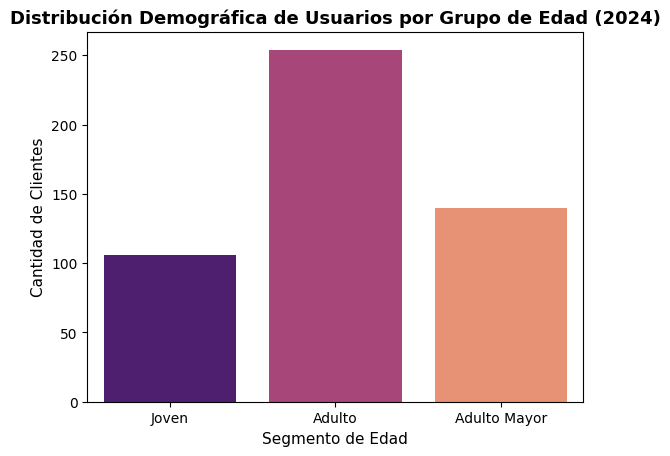

In [178]:
# Visualización de los segmentos por edad
# Ordenamos las barras de menor a mayor rango de edad
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    order=orden_edad, 
    palette='magma'  # Otra paleta llamativa y bien diferenciada
)

# Título y etiquetas del eje para edad
plt.title('Distribución Demográfica de Usuarios por Grupo de Edad (2024)', fontsize=13, fontweight='bold')
plt.xlabel('Segmento de Edad', fontsize=11)
plt.ylabel('Cantidad de Clientes', fontsize=11)

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Inconsistencia y desconexión en el enlace de datos: Al inicio, la tabla de perfiles de usuario (user_profile) no estaba correctamente vinculada con las tablas de consumo mensual. Esto provocaba que variables críticas como cant_mensajes, cant_llamadas y cant_minutos_llamada aparecieran vacías, en cero o con valores estáticos que no reflejaban la realidad.
- Impacto cuantitativo: Este problema afectaba al 100% de las filas de la muestra analizada (500 usuarios), invalidando cualquier intento de análisis descriptivo. Al corregir las uniones (joins/merges) utilizando el identificador único user_id, logramos poblar dinámicamente el total de los registros con consumos reales del año 2024.


🔍 **Segmentos por Edad**
- Los Adultos (30-59 años): Es el grupo más grande con 254 usuarios (más de la mitad, el 50.8%). Son los que mantienen estable el negocio porque consumen de todo un poco.

- Los Adultos Mayores (60+ años): Son el segundo grupo más grande con 140 usuarios (28%).

- Jóvenes (<30 años): Son la minoría, solo el 21.2% (106 usuarios). Aquí hay una oportunidad enorme para marketing y atraer a más gente joven. 


📊 **Segmentos por Nivel de Uso**
- Los de Bajo y Medio uso : Vimos que los usuarios del plan economico (Smart) miden cada mensaje y llamada para no pasarse de su límite y que no les cobren de más.

- El truco del "Alto uso": Como usamos el operador & de forma estricta, si un usuario se vuelve loco usando solo una cosa (por ejemplo, alguien que no llama nunca pero manda 800 mensajes), el sistema lo manda directo a Alto uso. Esto nos demostró que hay muchos clientes "híbridos" que gastan un montón de un solo servicio.


➡️ Esto sugiere que;
El comportamiento de los clientes está fuertemente moldeado por la barrera del límite de su plan. En el análisis de mensajes y minutos, el plan premium (Ultra) demostró cumplir con éxito su promesa de valor: al eliminar la fricción del límite de consumo, el usuario premium se relaja, extiende la duración de sus llamadas (desplazando su pico en el histograma hacia la derecha) y envía más mensajes. En contraste, en la métrica de cant_llamadas, ambos planes se comportan igual (hacen la misma cantidad de intentos de llamada). Esto demuestra que el valor real que consume y agradece el cliente Ultra es el TIEMPO de conversación (minutos acumulados) y no la acción de marcar el teléfono.

💡 **Recomendaciones**
- Campañas de Marketing enfocadas en la "Libertad de Tiempo": Promocionar el plan Ultra bajo el concepto de "Llamadas sin mirar el reloj" o "Conversaciones sin límite", ya que los datos confirman que los usuarios premium compran el plan para hablar más tiempo por llamada, no para llamar más veces.

- Creación de un Plan Intermedio ("Plan Connecta-Híbrido"): Diseñar una tarifa intermedia para mitigar el salto drástico hacia "Alto uso". Un plan enfocado en usuarios que consumen muchos datos/mensajes pero pocas llamadas (o viceversa) retendría a clientes que hoy se sienten limitados en el plan Smart pero que no desean pagar el costo total del plan Ultra.

- Oferta Especial para el "Adulto Mayor": Dado que representan el 28% de la base de clientes y biológicamente tienden a preferir la comunicación por voz sobre los mensajes de texto, ConnectaTel podría lanzar un paquete enfocado exclusivamente en minutos ilimitados hacia números frecuentes familiares, capturando la lealtad de este enorme nicho. 


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`